<img style="text-align: center" src='https://ensim.univ-lemans.fr/skins/ensim/resources/um_img/menu-gauche/lemans-universite-large.png' width="300" height="80">
<br>

<div style="margin-bottom:30px">
    <h1 style="text-align: center; color:#00B0F0; font-family:Sylfaen; font-size:34px;">Visualisation et exploration des donn?es</h1>
</div>

<div style="margin-bottom:30px">
    <h2 style="text-align: center; color:#00B0F0; font-family:Sylfaen; font-size:28px;">Projet</h2>
</div>

<div style="margin-bottom:20px">
    <p style="text-align: center; font-size:16px;">
        Objectif : EDA + Visualisation + Pr?paration des variables + Mod?lisation + Ciblage client
    </p>
</div>

---




## Organisation du notebook

1. **Préparation & chargement**
2. **Inspection rapide & qualité des données**
3. **Statistiques descriptives**
4. **Visualisation univariée**
5. **Analyse de la cible**
6. **Relations entre variables**
7. **Feature engineering**
8. **Préprocessing & modélisation**
9. **Prédictions sur les clients à contacter**
10. **Conclusion métier rédigée**


## Enoncé du problème

Une compagnie souhaite identifier les clients les plus pertinents à contacter pour une souscription.

Le fichier `train_info.csv` contient des clients avec une cible `reponse_client` indiquant s'ils ont répondu positivement ou non. Le fichier `clients_a_contacter.csv` contient les clients pour lesquels on veut produire une recommandation de contact.

L'objectif est de :
- comprendre les données,
- visualiser les profils clients,
- construire un modèle prédictif,
- générer une liste de ciblage exploitable.


# 0) Préparation

## 0.1 Imports
On utilisera : `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly` et `scikit-learn`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
%matplotlib inline


def show_plotly(fig):
    try:
        fig.show()
    except Exception as e:
        print("Affichage Plotly inline indisponible dans cet environnement.")
        print("Erreur:", e)
        print("Tentative d'ouverture dans le navigateur...")
        fig.show(renderer="browser")


## 0.2 Chemins de travail
Le notebook est prévu pour être exécuté depuis le dossier `Projet/`.


In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"

if not DATA_DIR.exists() and (BASE_DIR / "Projet" / "Data").exists():
    BASE_DIR = BASE_DIR / "Projet"
    DATA_DIR = BASE_DIR / "Data"

train_path = DATA_DIR / "train_info.csv"
prospects_path = DATA_DIR / "clients_a_contacter.csv"

print("BASE_DIR:", BASE_DIR)
print("train exists:", train_path.exists())
print("prospects exists:", prospects_path.exists())


BASE_DIR: c:\Users\Mayah\Desktop\4A\Visu des donnees\Projet
train exists: True
prospects exists: True


# 1) Chargement des données

## 1.1 Chargement des fichiers


In [3]:
train_df = pd.read_csv(train_path)
prospects_df = pd.read_csv(prospects_path)

print("Train shape:", train_df.shape)
print("Prospects shape:", prospects_df.shape)


Train shape: (381109, 12)
Prospects shape: (127037, 11)


+ Afficher les premières lignes des deux datasets.


In [4]:
display(train_df.head())
display(prospects_df.head())


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete
0,381110,male,25,1,11.0,1,< 1 an,no,35786.0,152.0,53
1,381111,male,40,1,28.0,0,1-2 an,oui,33762.0,7.0,111
2,381112,male,47,1,28.0,0,1-2 an,oui,40050.0,124.0,199
3,381113,male,24,1,27.0,1,< 1 an,oui,37356.0,152.0,187
4,381114,male,27,1,28.0,1,< 1 an,no,59097.0,152.0,297


# 2) Inspection rapide & qualité des données

## 2.1 Structure des données
Questions :
1. Combien de lignes et de colonnes ?
2. Quels sont les types des colonnes ?
3. Y a-t-il des valeurs manquantes ?
4. Quelles colonnes semblent être des identifiants ?


In [5]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_client            381109 non-null  int64  
 1   genre                381109 non-null  object 
 2   age                  381109 non-null  int64  
 3   permis_conduire      381109 non-null  int64  
 4   code_regional        381109 non-null  float64
 5   ancien_assure        381109 non-null  int64  
 6   age_vehicule         381109 non-null  object 
 7   vehicule_endommage   381109 non-null  object 
 8   prime_annuelle       381109 non-null  float64
 9   canal_communication  381109 non-null  float64
 10  anciennete           381109 non-null  int64  
 11  reponse_client       381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [6]:
train_df.shape, prospects_df.shape


((381109, 12), (127037, 11))

## 2.2 Valeurs manquantes, doublons, unicité de l'identifiant


In [7]:
missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_prospects = prospects_df.isna().sum().sort_values(ascending=False)

print("Valeurs manquantes - train")
display(missing_train.to_frame("missing"))

print("Valeurs manquantes - prospects")
display(missing_prospects.to_frame("missing"))

print("Doublons train:", train_df.duplicated().sum())
print("Doublons prospects:", prospects_df.duplicated().sum())
print("id_client unique dans train:", train_df["id_client"].is_unique)
print("id_client unique dans prospects:", prospects_df["id_client"].is_unique)


Valeurs manquantes - train


,missing
id_client,0
genre,0
age,0
permis_conduire,0
code_regional,0
ancien_assure,0
age_vehicule,0
vehicule_endommage,0
prime_annuelle,0
canal_communication,0


Valeurs manquantes - prospects


,missing
id_client,0
genre,0
age,0
permis_conduire,0
code_regional,0
ancien_assure,0
age_vehicule,0
vehicule_endommage,0
prime_annuelle,0
canal_communication,0


Doublons train: 0
Doublons prospects: 0
id_client unique dans train: True
id_client unique dans prospects: True


## 2.3 Typologie des variables
On distingue ici :
- l'identifiant : `id_client`
- la cible : `reponse_client`
- les variables quantitatives
- les variables catégorielles texte
- les variables binaires codées en nombres
- les variables codées numériquement mais à interpréter comme catégories


In [9]:
id_col = "id_client"
target_col = "reponse_client"

binary_cols = ["permis_conduire", "ancien_assure"]
text_cat_cols = ["genre", "age_vehicule", "vehicule_endommage"]
code_like_cols = ["code_regional", "canal_communication"]
numeric_cols = ["age", "prime_annuelle", "anciennete"]

summary_types = pd.DataFrame(
    {
        "role": [
            "identifiant",
            "catégorielle",
            "quantitative",
            "binaire",
            "catégorie codée",
            "binaire",
            "catégorielle ordinale",
            "catégorielle binaire",
            "quantitative",
            "catégorie codée",
            "quantitative",
            "cible",
        ]
    },
    index=train_df.columns,
)
summary_types


,role
id_client,identifiant
genre,catégorielle
age,quantitative
permis_conduire,binaire
code_regional,catégorie codée
ancien_assure,binaire
age_vehicule,catégorielle ordinale
vehicule_endommage,catégorielle binaire
prime_annuelle,quantitative
canal_communication,catégorie codée


# 3) Statistiques descriptives

## 3.1 Variables quantitatives


In [10]:
train_df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
prime_annuelle,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
anciennete,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0


## 3.2 Variables binaires et catégorielles


In [12]:
for col in ["genre", "age_vehicule", "vehicule_endommage", "permis_conduire", "ancien_assure"]:
    print(f"{col}")
    display(train_df[col].value_counts(dropna=False).to_frame("effectif"))


genre


,effectif
genre,
male,206089
femelle,175020


age_vehicule


,effectif
age_vehicule,
1-2 an,200316
< 1 an,164786
> 2 ans,16007


vehicule_endommage


,effectif
vehicule_endommage,
oui,192413
no,188696


permis_conduire


,effectif
permis_conduire,
1,380297
0,812


ancien_assure


,effectif
ancien_assure,
0,206481
1,174628


## 3.3 Détection simple des valeurs aberrantes
On utilise ici la régle de l'IQR sur les variables quantitatives.


In [13]:
outlier_rows = []

for col in numeric_cols:
    s = train_df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_outliers = ((s < low) | (s > high)).sum()
    outlier_rows.append(
        {
            "variable": col,
            "seuil_bas": low,
            "seuil_haut": high,
            "nb_outliers": int(n_outliers),
            "pct_outliers": n_outliers / len(s),
            "min": s.min(),
            "max": s.max(),
        }
    )

pd.DataFrame(outlier_rows)


,variable,seuil_bas,seuil_haut,nb_outliers,pct_outliers,min,max
0,age,-11.0,85.0,0,0.000000,20.0,85.0
1,prime_annuelle,1912.5,61892.5,10320,0.027079,2630.0,540165.0
2,anciennete,-135.5,444.5,0,0.000000,10.0,299.0


# 4) Visualisation univariée

## 4.1 Distributions des variables quantitatives


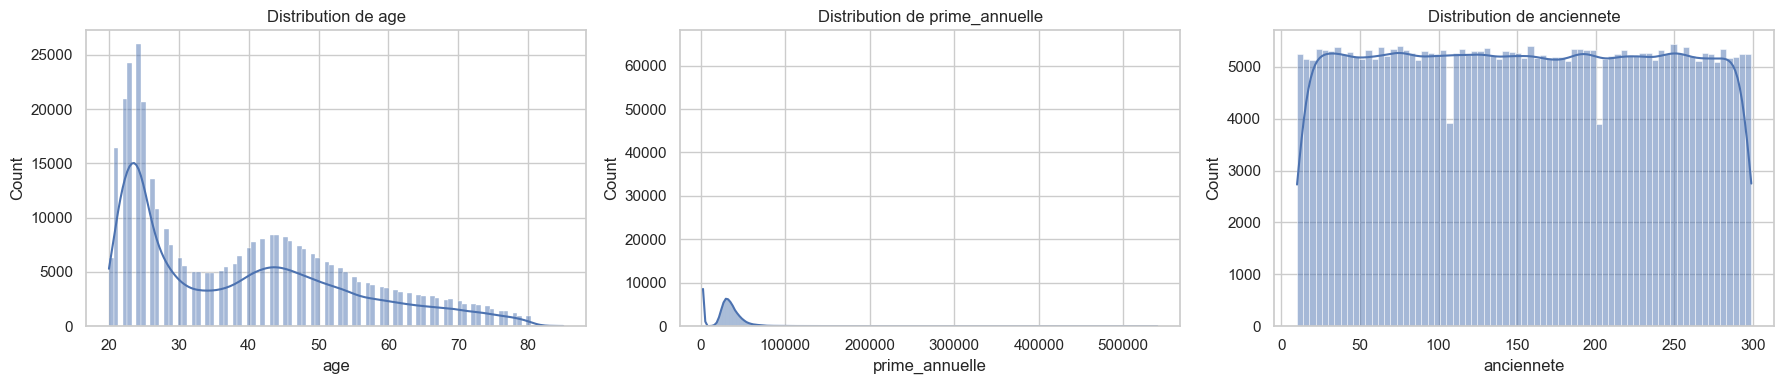

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.show()


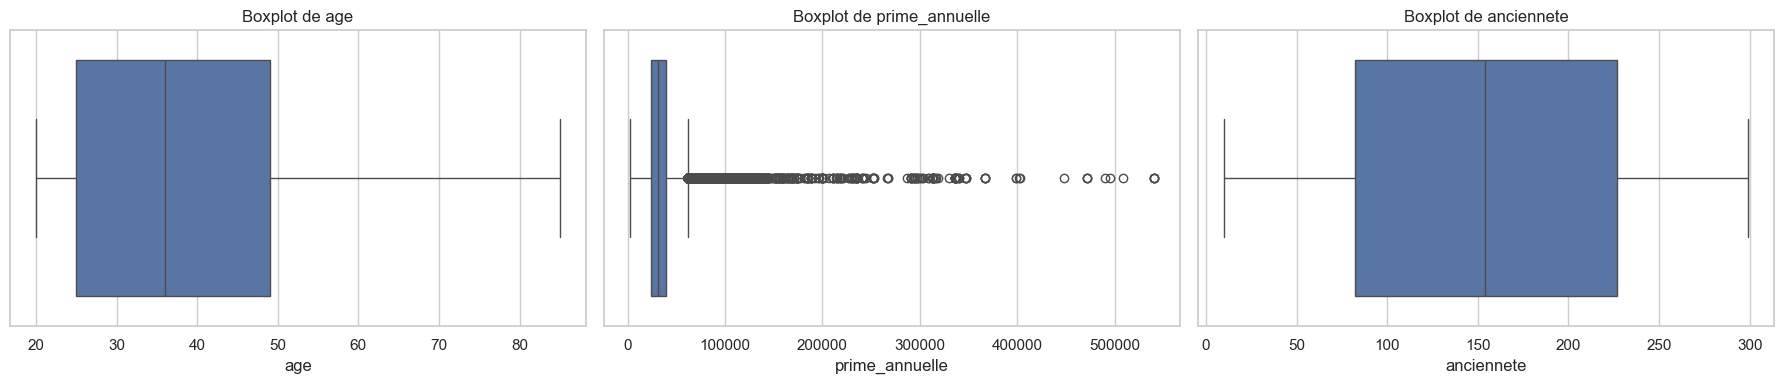

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=train_df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


## 4.2 Distributions des variables catégorielles


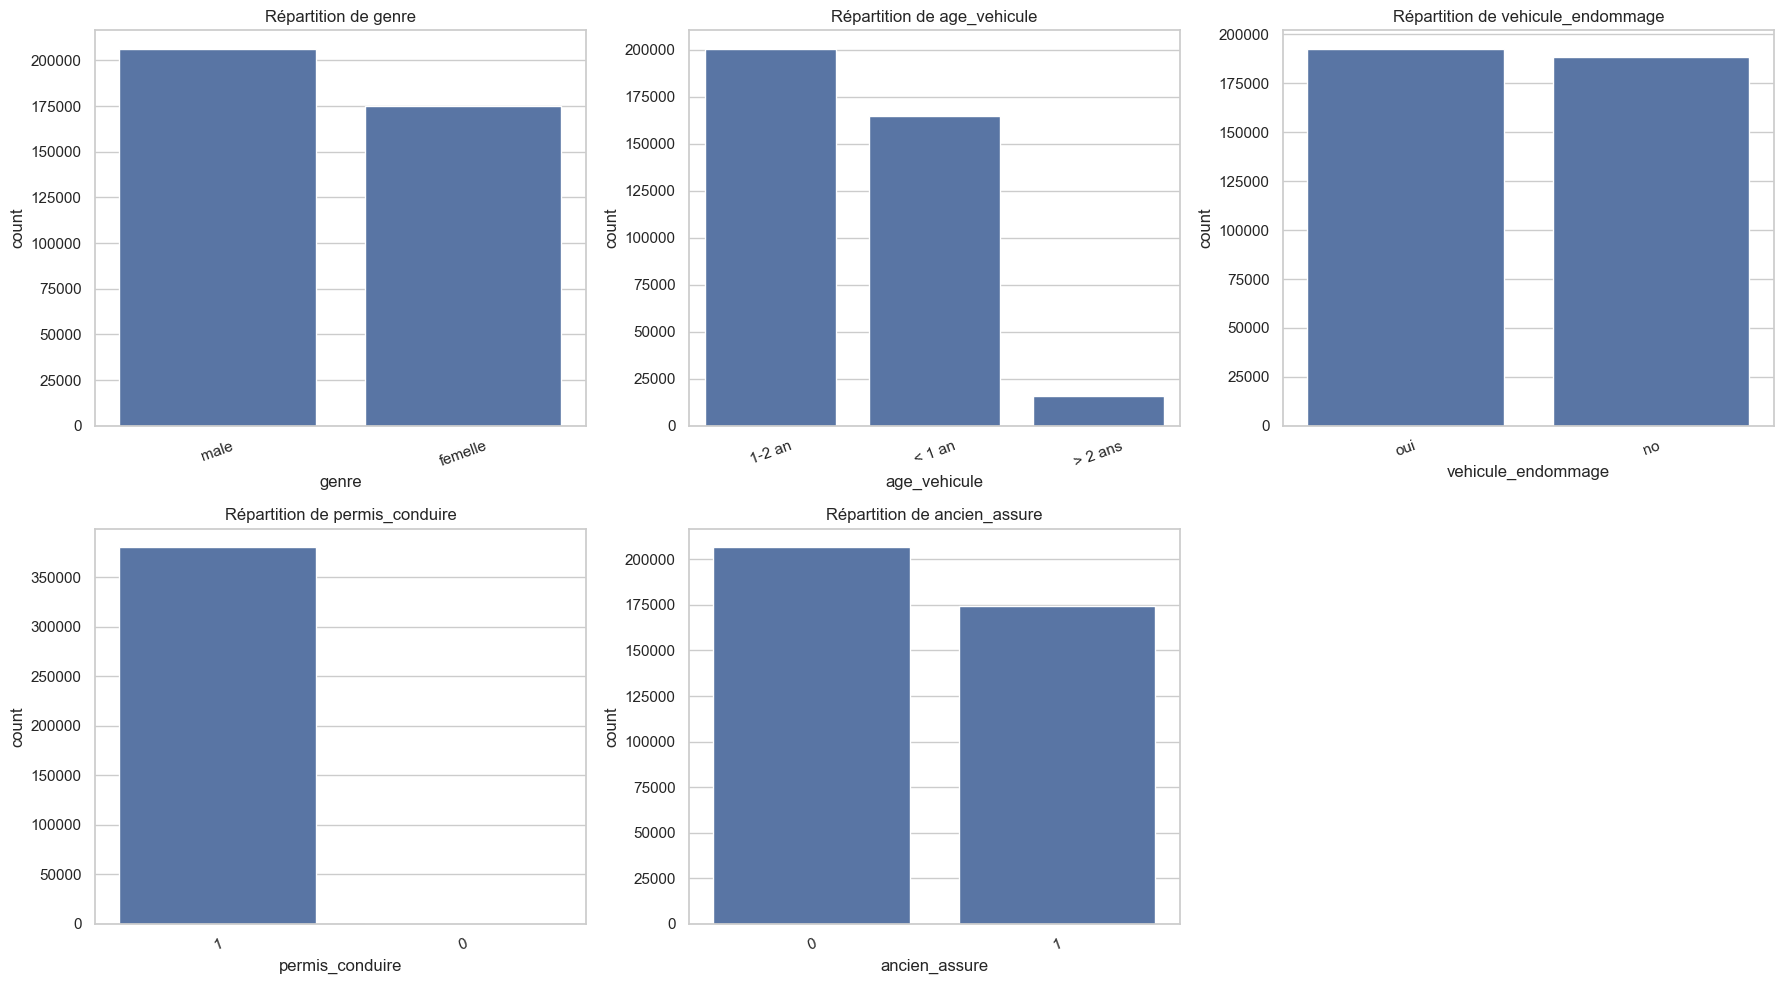

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plot_cols = ["genre", "age_vehicule", "vehicule_endommage", "permis_conduire", "ancien_assure"]

for ax, col in zip(axes, plot_cols):
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, order=order, ax=ax)
    ax.set_title(f"Répartition de {col}")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 5) Analyse de la cible

La variable cible est `reponse_client`. On vérifie son équilibre puis on regarde comment elle varie selon quelques caractéristiques client.


In [17]:
target_dist = train_df[target_col].value_counts(normalize=True).sort_index().rename("proportion")
display(target_dist.to_frame())

fig = px.bar(
    train_df[target_col].value_counts().sort_index().reset_index(),
    x="reponse_client",
    y="count",
    title="Distribution de la cible reponse_client",
)
show_plotly(fig)


,proportion
reponse_client,
0,0.877437
1,0.122563


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [19]:
for col in ["genre", "age_vehicule", "vehicule_endommage", "ancien_assure", "permis_conduire"]:
    tmp = train_df.groupby(col, dropna=False)[target_col].mean().sort_values(ascending=False)
    print(f"Taux de réponse par {col}")
    display(tmp.to_frame("taux_reponse"))


Taux de réponse par genre


,taux_reponse
genre,
male,0.138411
femelle,0.103902


Taux de réponse par age_vehicule


,taux_reponse
age_vehicule,
> 2 ans,0.293746
1-2 an,0.173755
< 1 an,0.043705


Taux de réponse par vehicule_endommage


,taux_reponse
vehicule_endommage,
oui,0.237655
no,0.005204


Taux de réponse par ancien_assure


,taux_reponse
ancien_assure,
0,0.225454
1,0.000905


Taux de réponse par permis_conduire


,taux_reponse
permis_conduire,
1,0.122717
0,0.050493


# 6) Relations entre variables

## 6.1 Corrélation de Spearman
On inclut ici les variables numériques et binaires codées en nombres.


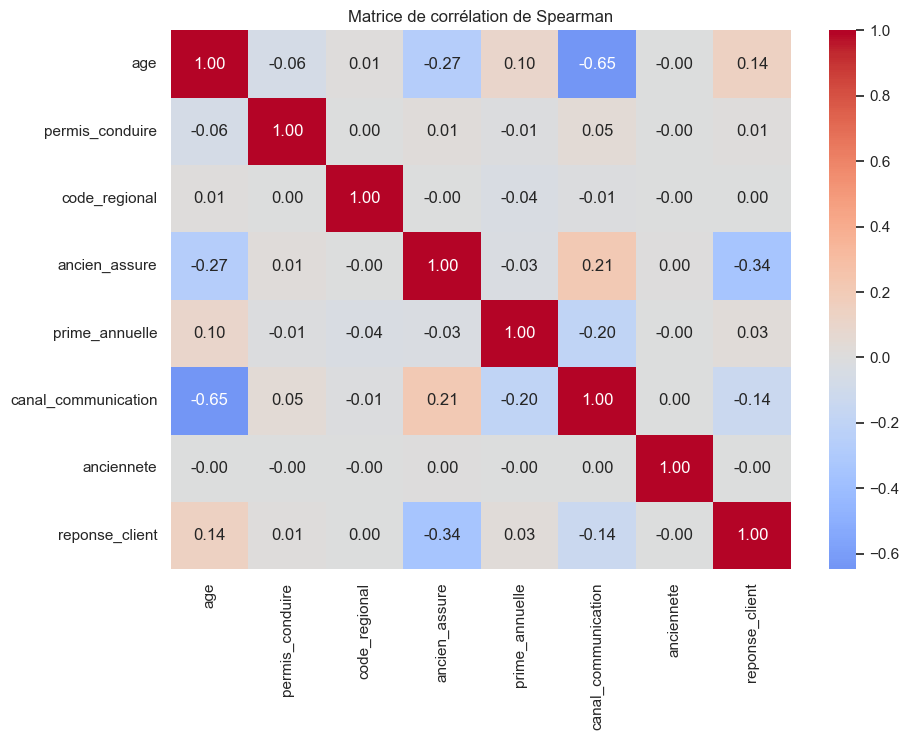

In [34]:
corr_cols = ["age", "permis_conduire", "code_regional", "ancien_assure", "prime_annuelle", "canal_communication", "anciennete", "reponse_client"]
spearman_corr = train_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation de Spearman")
plt.show()


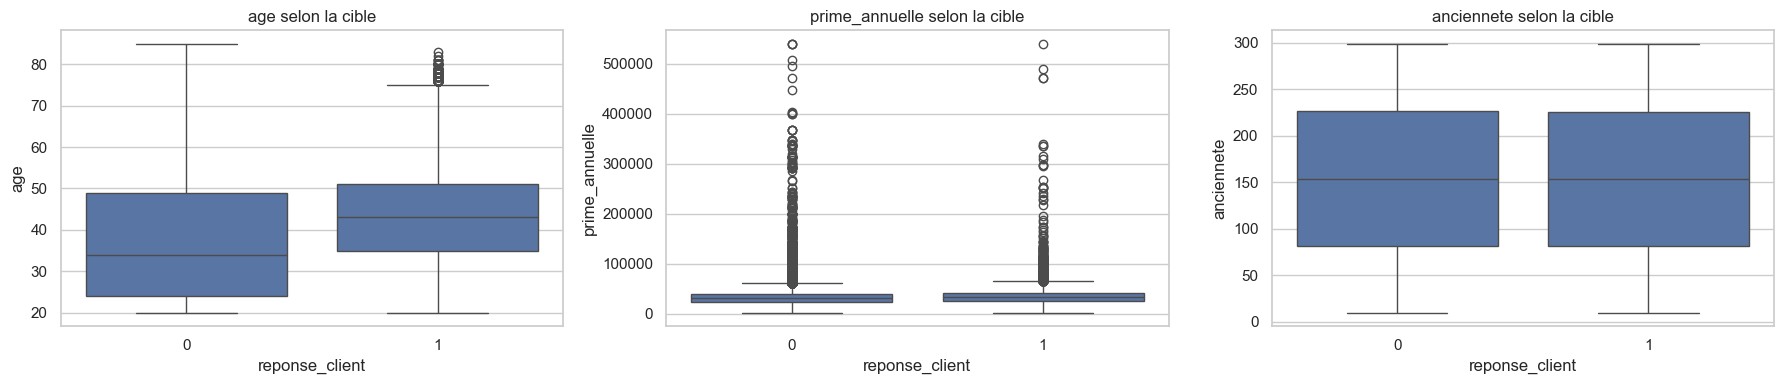

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=train_df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} selon la cible")
plt.tight_layout()
plt.show()


# 7) Feature engineering

On construit ici quelques variables simples inspirées du sujet :
- `tranche_age`
- encodage ordinal de `age_vehicule`
- variable d'interaction entre dommage véhicule et ancien assuré
- encodage métier simple pour les variables à forte cardinalité via le taux moyen de réponse observé sur l'échantillon d'entraînement


In [22]:
def add_features(df):
    df = df.copy()

    df["tranche_age"] = pd.cut(
        df["age"],
        bins=[18, 25, 30, 35, 45, 55, 65, 100],
        labels=["18-25", "26-30", "31-35", "36-45", "46-55", "56-65", "66+"],
        include_lowest=True,
    )

    age_vehicle_map = {"< 1 an": 0, "1-2 an": 1, "> 2 ans": 2}
    damage_map = {"no": 0, "oui": 1}

    df["age_vehicule_ord"] = df["age_vehicule"].map(age_vehicle_map)
    df["vehicule_endommage_bin"] = df["vehicule_endommage"].map(damage_map)

    df["interaction_dommage_assure"] = (
        df["vehicule_endommage"].astype(str) + "_" + df["ancien_assure"].astype(str)
    )

    return df

train_fe = add_features(train_df)
prospects_fe = add_features(prospects_df)

train_fe.head()


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,tranche_age,age_vehicule_ord,vehicule_endommage_bin,interaction_dommage_assure
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1,36-45,2,1,oui_0
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0,66+,1,0,no_0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1,46-55,2,1,oui_0
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0,18-25,0,0,no_1
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0,26-30,0,0,no_1


In [24]:
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols or []
        self.global_mean_ = None
        self.maps_ = {}

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y)
        self.global_mean_ = float(y.mean())
        for col in self.cols:
            tmp = pd.DataFrame({col: X[col], "target": y})
            self.maps_[col] = tmp.groupby(col)["target"].mean().to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in self.cols:
            out[col + "_mean_target"] = X[col].map(self.maps_[col]).fillna(self.global_mean_)
        return out


## Ce qu'on entra?ne exactement

Dans `train_info.csv`, chaque ligne correspond ? un client d?j? observ? avec une **r?ponse connue** :
- `reponse_client = 1` : le client a r?pondu positivement,
- `reponse_client = 0` : le client n'a pas r?pondu positivement.

Le but est donc d'entra?ner un **mod?le de classification supervis?e binaire**.

Concr?tement :
- les **variables explicatives** sont les caract?ristiques client (`genre`, `age`, `ancien_assure`, `age_vehicule`, `prime_annuelle`, etc.),
- la **variable cible** est `reponse_client`.

Le mod?le apprend ? partir du fichier `train_info.csv` une r?gle qui estime :
- soit une **classe pr?dite** (`0` ou `1`),
- soit une **probabilit? de r?ponse positive**.

C'est cette probabilit? qui sera ensuite utilis?e sur `clients_a_contacter.csv` pour prioriser les clients ? contacter.


# 8) Pr?processing & mod?lisation

## 8.1 S?paration train / test

On s?pare les donn?es en deux parties :
- un sous-ensemble d'entra?nement pour apprendre le mod?le,
- un sous-ensemble de test pour ?valuer ses performances sur des donn?es non vues.

Cette ?tape est indispensable pour v?rifier que le mod?le g?n?ralise correctement.


In [25]:
feature_cols = [
    "genre",
    "age",
    "permis_conduire",
    "code_regional",
    "ancien_assure",
    "age_vehicule",
    "vehicule_endommage",
    "prime_annuelle",
    "canal_communication",
    "anciennete",
    "tranche_age",
    "age_vehicule_ord",
    "vehicule_endommage_bin",
    "interaction_dommage_assure",
]

target = train_fe[target_col]
X = train_fe[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.25,
    random_state=42,
    stratify=target,
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(285831, 14) (95278, 14) (285831,) (95278,)


In [26]:
one_hot_cols = ["genre", "tranche_age", "interaction_dommage_assure"]
numeric_model_cols = [
    "age",
    "permis_conduire",
    "ancien_assure",
    "prime_annuelle",
    "anciennete",
    "age_vehicule_ord",
    "vehicule_endommage_bin",
]
high_card_cols = ["code_regional", "canal_communication"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            one_hot_cols,
        ),
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_model_cols,
        ),
        (
            "mean_target",
            MeanTargetEncoder(cols=high_card_cols),
            high_card_cols,
        ),
    ],
    remainder="drop",
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
}


In [27]:
results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    row = {
        "modele": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    results.append(row)
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df


,modele,precision,recall,f1,roc_auc
0,LogisticRegression,0.282227,0.917880,0.431713,0.851281
1,RandomForest,0.360852,0.119027,0.179008,0.833460


In [29]:
best_model_name = results_df.iloc[0]["modele"]
best_pipe = trained_pipelines[best_model_name]

print("Meilleur modèle:", best_model_name)

y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))


Meilleur modèle: LogisticRegression
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     83600
           1       0.28      0.92      0.43     11678

    accuracy                           0.70     95278
   macro avg       0.63      0.80      0.62     95278
weighted avg       0.90      0.70      0.75     95278

Confusion matrix:
[[56339 27261]
 [  959 10719]]


# 9) Pr?dictions sur les clients ? contacter

On applique exactement les m?mes transformations au fichier `clients_a_contacter.csv`.


In [30]:
X_prospects = prospects_fe[feature_cols].copy()
prospects_predictions = prospects_fe[["id_client"]].copy()
prospects_predictions["proba_reponse"] = best_pipe.predict_proba(X_prospects)[:, 1]
prospects_predictions["classe_predite"] = best_pipe.predict(X_prospects)

# Exemple simple de segmentation m?tier
prospects_predictions["segment_contact"] = pd.cut(
    prospects_predictions["proba_reponse"],
    bins=[0, 0.3, 0.7, 1.0],
    labels=["faible_priorite", "priorite_intermediaire", "haute_priorite"],
    include_lowest=True,
)

prospects_predictions = prospects_predictions.sort_values("proba_reponse", ascending=False)
prospects_predictions.head(20)


,id_client,proba_reponse,classe_predite,segment_contact
114728,495838,0.994945,1,haute_priorite
40907,422017,0.993462,1,haute_priorite
93997,475107,0.990915,1,haute_priorite
74751,455861,0.917961,1,haute_priorite
84033,465143,0.916033,1,haute_priorite
81127,462237,0.914758,1,haute_priorite
6819,387929,0.912146,1,haute_priorite
62939,444049,0.909371,1,haute_priorite
88086,469196,0.906608,1,haute_priorite
94045,475155,0.906600,1,haute_priorite


In [31]:
output_path = BASE_DIR / "predictions_clients_a_contacter.csv"
prospects_predictions.to_csv(output_path, index=False)
print("Fichier export?:", output_path)


Fichier export?: c:\Users\Mayah\Desktop\4A\Visu des donnees\Projet\predictions_clients_a_contacter.csv


In [33]:
fig = px.histogram(
    prospects_predictions,
    x="proba_reponse",
    nbins=40,
    color="segment_contact",
    title="Distribution des probabilit?s pr?dites",
)
show_plotly(fig)


NameError: name 'show_plotly' is not defined

# 10) Conclusion m?tier

## Conclusion r?dig?e

L'analyse exploratoire montre que le jeu de donn?es est globalement propre : il ne contient pas de valeurs manquantes, pas de doublons complets et l'identifiant `id_client` est unique. Les principales variables quantitatives sont `age`, `prime_annuelle` et `anciennete`. Les variables `genre`, `age_vehicule` et `vehicule_endommage` jouent un r?le important dans la lecture m?tier du dataset. On note ?galement que `code_regional` et `canal_communication` sont des codes num?riques qu'il vaut mieux interpr?ter comme des cat?gories plut?t que comme des variables quantitatives classiques.

La variable cible `reponse_client` est d?s?quilibr?e : environ 12 % des clients r?pondent positivement, contre 88 % de r?ponses n?gatives. Ce point justifie l'utilisation de m?triques adapt?es comme le rappel, le F1-score et le ROC-AUC. L'EDA met aussi en ?vidence plusieurs signaux utiles : les clients dont le v?hicule a d?j? ?t? endommag? r?pondent beaucoup plus souvent positivement, les v?hicules plus anciens sont davantage associ?s ? une r?ponse positive, et certains sous-profils clients semblent donc nettement plus prometteurs que d'autres.

Dans la partie mod?lisation, on entra?ne un classifieur supervis? binaire pour pr?dire `reponse_client` ? partir des caract?ristiques client. L'id?e n'est pas seulement d'obtenir une classe 0/1, mais surtout une **probabilit? de r?ponse positive**. Cette probabilit? est la sortie la plus utile d'un point de vue m?tier, car elle permet de classer les clients et de construire une strat?gie de contact prioris?e. Une premi?re r?gression logistique constitue une bonne base d'interpr?tation. Un mod?le plus flexible comme une for?t al?atoire peut aussi ?tre test? pour am?liorer la qualit? pr?dictive.

Enfin, l'application du meilleur pipeline sur `clients_a_contacter.csv` permet de produire un fichier de scores exploitable commercialement. La recommandation m?tier consiste ? ne pas contacter indistinctement tous les clients, mais ? cibler en priorit? ceux dont la probabilit? pr?dite est ?lev?e ou interm?diaire selon la strat?gie retenue. Le projet peut ainsi d?boucher sur trois livrables coh?rents : un notebook d'analyse et de mod?lisation, un fichier de pr?dictions pour le ciblage client, et un dashboard Streamlit pour pr?senter les r?sultats de mani?re claire et interactive.

## Livrables associ?s

- ce notebook d'analyse et de mod?lisation,
- le fichier `predictions_clients_a_contacter.csv`,
- l'application Streamlit,
- un rapport synth?tique de 2 ? 4 pages.
